# Testing the noise covariance using fgbuster

The goal here is to import the noise covariance computed in the pipeline and see if the reults coming out of fgbuster are correct

The test will follow these general steps:
 1. First we will use the full sky data and noise covariance before preprocessing. This should give a close to perfect result.
 2. Then we will do the same on data and noise covariance **after** preprocessing.
 3. Then we go back to data and noise cov **before** preprocessing, but this time a mak and nhits we have been repectively applied to the data and the noise sims used to compute the noise covariance.
 4. Finally we will perform the test on the most realistic case, with **preproceseed** and masked data and noise-covariance
 5. We will also test the importance of using a noise covariance that was built using noise map simulations that went through preprocessing. To test this we will use data that went through preprocessing, but a noise covariance that did not (but we still apply the nhits maps to the it)

# 1) Full sky, before preprocessing


In [2]:
#  Importing the relevant libraries
import numpy as np
import matplotlib.pyplot as plt
import fgbuster as fg
from fgbuster.component_model import CMB, Dust, Synchrotron
from megatop import BBmeta
import healpy as hp
import os
import time
from pysm3 import Sky
import scipy

In [3]:
#  For this test the simulated data and outputs are stored in /pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32NONhits
# Let's set up the meta_sims and meta objects.
args = classmethod(None)
args.sims = '/pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32NONhits/OnTheFlySims/config.yaml'
args.globals = '/pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32NONhits/outputs/config.yaml'

meta_sims = BBmeta(args.sims)
meta = BBmeta(args.globals)

In [4]:
# Now let's load the data for the first simulation.
sim_num = 1
freq_maps_full_sky_beforepreproc = np.load(os.path.join(meta_sims.comb_directory, 'comb_freq_maps_SIM'+str(sim_num).zfill(5)+'.npy' ))

#  And the relevant noise covariance matrix
# careful, the noise covariance is a product of the pipeline (different from simulations) and its relevant parameters/path are stored in the meta object (not meta_sims)
noise_cov_full_sky_beforepreproc = np.load(os.path.join(meta.covmat_directory, 'pixel_noise_cov.npy' ))

Frequency =  93 GHz


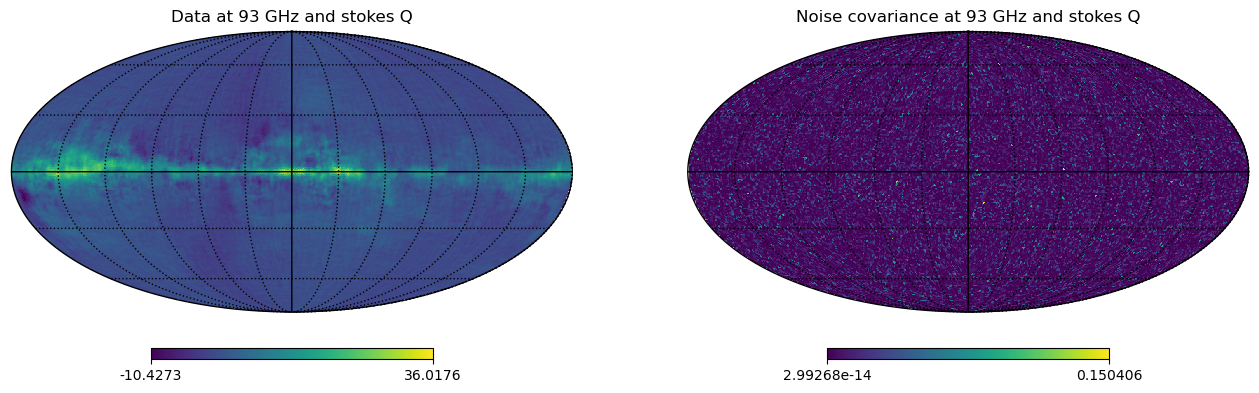

In [5]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_full_sky_beforepreproc[freq_index, stokes_index, :], title='Data at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_full_sky_beforepreproc[freq_index, stokes_index, :], title='Noise covariance at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()


In [6]:
# Now let's set up the component separation
instrument = {'frequency': meta.frequencies}
components = [CMB(), Dust(150., temp=20.0), Synchrotron(150.)] # we leave T_dust fixed at 20 K

# Minimization options, copied from BBPipe
options={'disp':False, 'gtol': 1e-12, 'eps': 1e-12, 'maxiter': 100, 'ftol': 1e-12 } 
tol=1e-18
method='TNC'

# And run the separation
time_comp_sep = time.time()
res_full_sky_beforepreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_full_sky_beforepreproc[:,1:], cov=noise_cov_full_sky_beforepreproc[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print(res_full_sky_beforepreproc)

time comp sep = 5.488035440444946
     Sigma: array([[ 1.25963648e-08, -1.52101626e-08],
       [-1.52101626e-08,  1.58422190e-07]])
 Sigma_inv: array([[89798588.66511787,  8621589.80853263],
       [ 8621589.80853263,  7140008.51026014]])
       chi: array([[[-9.97579066e-02,  2.77447530e+00, -8.87069115e-01, ...,
          2.34614906e+00,  2.03815720e-01, -3.22350914e-01],
        [-1.61320031e+00, -1.18382240e-01, -1.99729977e-01, ...,
         -3.74919902e-01, -1.10329476e-01, -4.77741706e-01]],

       [[ 1.30319772e-01,  2.92214990e-01,  1.23912730e+00, ...,
         -6.22781655e-02, -2.59534274e-01,  1.42904594e+00],
        [ 4.28689864e-01,  2.49398644e+00,  5.23883999e-01, ...,
          1.90646384e+00,  4.38175573e-02,  1.40773001e+00]],

       [[ 2.46634667e-01, -2.93391171e+00,  1.53515634e-01, ...,
          1.28376817e+00, -1.39060617e+00,  2.52771331e-01],
        [-1.64733438e+00, -6.54794723e-01,  3.44822395e-01, ...,
         -9.13872831e-01,  2.13276288e+00,  2.103

In [7]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_full_sky_beforepreproc.Sigma)

    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_full_sky_beforepreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_full_sky_beforepreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)  

    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_full_sky_beforepreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_full_sky_beforepreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_full_sky_beforepreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_full_sky_beforepreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_full_sky_beforepreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_full_sky_beforepreproc.x[1])/ sigma_from_fisher[1,1] )
    

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5389807916787601
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.9576922276243196
Estimated error matrix = 
 [[ 1.08116586e-04 -3.01192408e-05]
 [-3.01192408e-05  3.96881621e-04]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0010192083212399172
Relative difference in dust index (in %) =  0.06618235852207255
Relative difference in dust index using ouptut Sigma =  9.426937713820267



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.0423077723756804
Relative difference in synchrotron index (in %) =  1.4102590791893466
Relative difference in synchrotron index using ouptut Sigma =  106.6004827082423


# 2) Data and noise covariance **after** preprocessing

In [8]:
# Let's import the pre-processed data and noise covariance matrix
freq_maps_full_sky_afterpreproc = np.load(os.path.join(meta.pre_process_directory, 'freq_maps_common_beamed'+str(sim_num).zfill(5)+'.npy' ))

noise_cov_full_sky_afterpreproc = np.load(os.path.join(meta.covmat_directory, 'pixel_noise_cov_preprocessed.npy' ))

Frequency =  93 GHz


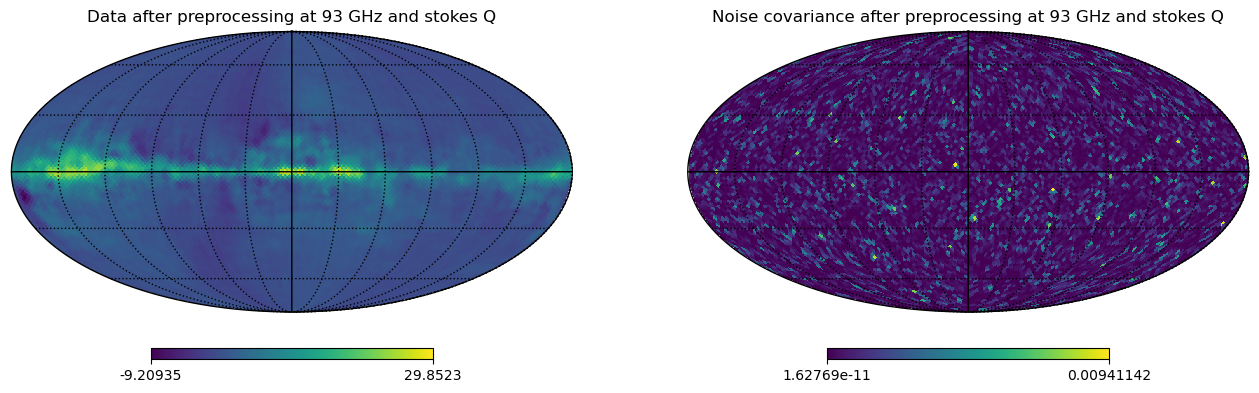

In [9]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_full_sky_afterpreproc[freq_index, stokes_index, :], title='Data after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_full_sky_afterpreproc[freq_index, stokes_index, :], title='Noise covariance after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()

In [10]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_full_sky_afterpreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_full_sky_afterpreproc[:,1:], cov=noise_cov_full_sky_afterpreproc[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print(res_full_sky_afterpreproc)

time comp sep = 1.7175407409667969
     Sigma: array([[ 4.36684357e-09, -7.65244197e-09],
       [-7.65244197e-09,  8.39020514e-08]])
 Sigma_inv: array([[2.72562117e+08, 2.48595327e+07],
       [2.48595327e+07, 1.41860194e+07]])
       chi: array([[[-1.59153893e-01, -4.25501159e-01, -9.54551059e-01, ...,
         -1.81023213e-01,  7.41567705e-01, -2.39052067e+00],
        [ 4.00481631e-01,  1.89276726e-02, -1.26744817e+00, ...,
          8.66598469e-01,  5.10086998e-01, -1.70010185e-03]],

       [[ 1.49717333e-01, -1.27336302e-01,  7.24329540e+00, ...,
         -2.87878522e-01,  7.18273727e-01,  5.51077135e-01],
        [-7.27624904e-01,  1.84337634e-01, -2.95687587e-01, ...,
          5.46069742e-02, -2.04796094e+00,  2.44993616e-01]],

       [[ 1.74468680e+00,  8.42426152e-01, -5.35831090e+00, ...,
          1.15299742e+00, -3.51964028e+00,  1.20627364e+00],
        [ 3.34952988e-01, -3.77363487e-01,  3.21948731e-01, ...,
         -5.76380801e-01,  2.41111697e+00, -6.71713336e-01]]

In [11]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_full_sky_afterpreproc.Sigma)
    
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_full_sky_afterpreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_full_sky_afterpreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)    

    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_full_sky_afterpreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_full_sky_afterpreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_full_sky_afterpreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_full_sky_afterpreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_full_sky_afterpreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_full_sky_afterpreproc.x[1])/ sigma_from_fisher[1,1] )
    

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5399981598409418
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.9999989456049745
Estimated error matrix = 
 [[ 6.23869560e-05 -2.17878705e-05]
 [-2.17878705e-05  2.88837913e-04]]


============= DUST INDEX ==============
Absolute difference in dust index =  1.8401590582417526e-06
Relative difference in dust index (in %) =  0.00011949084793777614
Relative difference in dust index using ouptut Sigma =  0.029495894297180227



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  1.0543950255126333e-06
Relative difference in synchrotron index (in %) =  3.5146500850421106e-05
Relative difference in synchrotron index using ouptut Sigma =  0.003650473076767497


# 3) Data and noise cov **before** preprocessing, **masked** 
This time a mask and nhits map has been repectively applied to the data and the noise sims used to compute the noise covariance.

In [12]:
#  For this test the simulated data and outputs are stored in /pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhits
# Let's set up the meta_sims and meta objects.
args_nhits = classmethod(None)
args_nhits.sims = '/pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhits/OnTheFlySims/config.yaml'
args_nhits.globals = '/pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhits/outputs/config.yaml'

meta_nhits_sims = BBmeta(args_nhits.sims)
meta_nhits = BBmeta(args_nhits.globals)

In [13]:
# Let's import the masked data and noise covariance matrix
binary_mask_sims = meta_nhits_sims.read_mask('binary').astype(bool)
freq_maps_masked_beforepreproc = np.load(os.path.join(meta_nhits_sims.comb_directory, 'comb_freq_maps_SIM'+str(sim_num).zfill(5)+'.npy' )) 
# Applying mask as it is not done in the simulation
freq_maps_masked_beforepreproc[..., np.where(binary_mask_sims == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)

# Importing the relevant noise covariance matrix
noise_cov_masked_beforepreproc = np.load(os.path.join(meta_nhits.covmat_directory, 'pixel_noise_cov.npy' )) 
# Putting masked pixels to UNSEEN (noise cov is natively masked when using nhits like in this case)
noise_cov_masked_beforepreproc[..., np.where(binary_mask_sims == 0)[0]] = hp.UNSEEN 


Frequency =  93 GHz


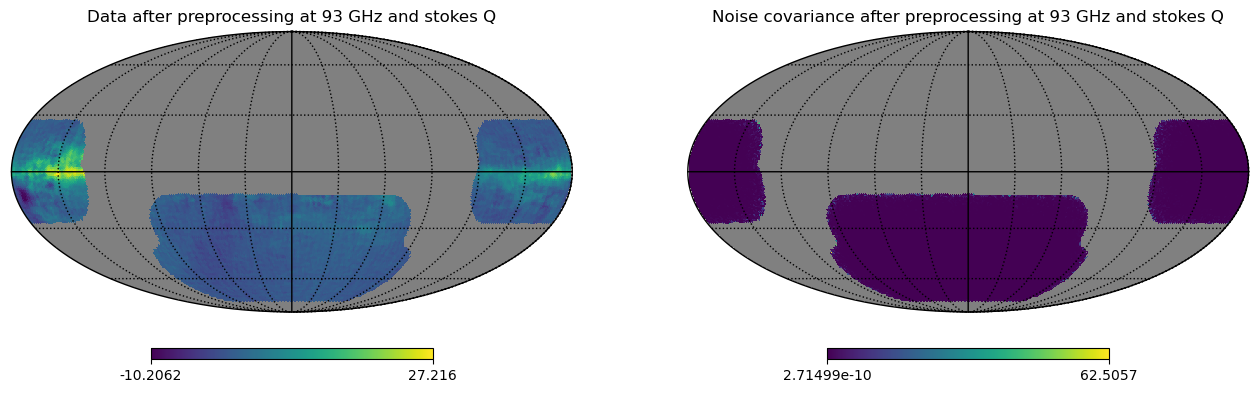

In [14]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_masked_beforepreproc[freq_index, stokes_index, :], title='Data after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_masked_beforepreproc[freq_index, stokes_index, :], title='Noise covariance after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()

In [15]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_masked_beforepreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_beforepreproc[:,1:], cov=noise_cov_masked_beforepreproc[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print(res_masked_beforepreproc)

time comp sep = 4.44471549987793
     Sigma: array([[ 6.45249552e-08, -1.46028875e-07],
       [-1.46028875e-07,  3.61653232e-06]])
 Sigma_inv: array([[17056527.79152124,   688710.99307748],
       [  688710.99307748,   304316.8409142 ]])
       chi: array([[[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375

In [16]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_beforepreproc.Sigma)
    
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_beforepreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_beforepreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)

    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_beforepreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_beforepreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_beforepreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_beforepreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_beforepreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_beforepreproc.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5410134981268784
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.9423899698317824
Estimated error matrix = 
 [[ 2.44726827e-04 -6.80715452e-05]
 [-6.80715452e-05  1.90049956e-03]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0010134981268783427
Relative difference in dust index (in %) =  0.06581156668041187
Relative difference in dust index using ouptut Sigma =  4.141344611110533



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.05761003016821764
Relative difference in synchrotron index (in %) =  1.920334338940588
Relative difference in synchrotron index using ouptut Sigma =  30.313098355076338


# 4)Most realistic case, with **preproceseed** and masked data and noise-covariance

In [17]:
# Let's import the masked data and noise covariance matrix
binary_mask = meta_nhits.read_mask('binary').astype(bool)
freq_maps_masked_afterpreproc = np.load(os.path.join(meta_nhits.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_num).zfill(5)+'.npy' )) 
# Applying mask as it is not done in the simulation
freq_maps_masked_afterpreproc[..., np.where(binary_mask == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)

# Importing the relevant noise covariance matrix
noise_cov_masked_afterpreproc = np.load(os.path.join(meta_nhits.covmat_directory, 'pixel_noise_cov_preprocessed.npy' )) 
# Putting masked pixels to UNSEEN (noise cov is natively masked when using nhits like in this case)
noise_cov_masked_afterpreproc[..., np.where(binary_mask == 0)[0]] = hp.UNSEEN 


Frequency =  93 GHz


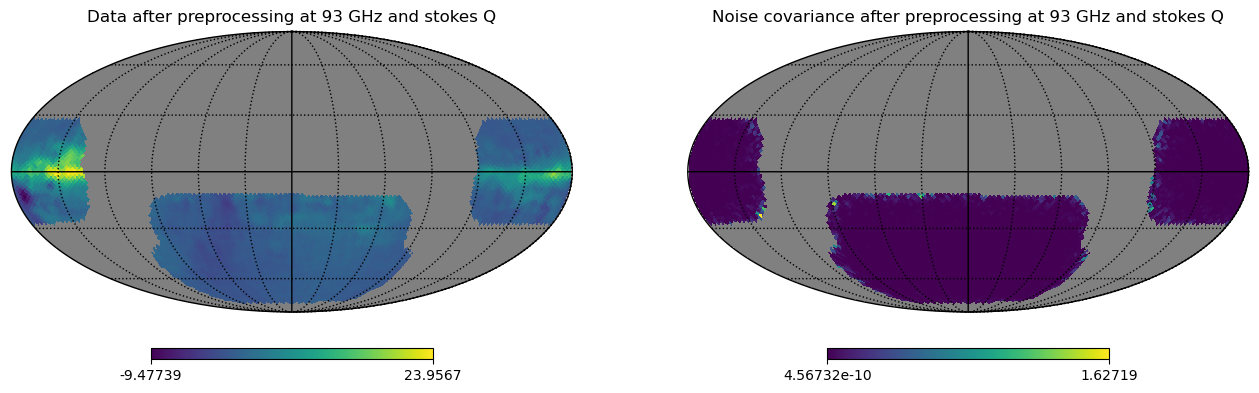

In [18]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_masked_afterpreproc[freq_index, stokes_index, :], title='Data after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_masked_afterpreproc[freq_index, stokes_index, :], title='Noise covariance after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()

In [19]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_masked_afterpreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc[:,1:], cov=noise_cov_masked_afterpreproc[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print(res_masked_afterpreproc)

time comp sep = 2.0632681846618652
     Sigma: array([[ 5.89636413e-08, -1.14369684e-07],
       [-1.14369684e-07,  1.87384167e-06]])
 Sigma_inv: array([[19237020.35563103,  1174129.04789291],
       [ 1174129.04789291,   605325.83159585]])
       chi: array([[[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.63

In [20]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_afterpreproc.Sigma)

    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_afterpreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_afterpreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)
    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5395836915782353
Input synchrotron index =  -3.0    Estimated synchrotron index =  -3.013240309496254
Estimated error matrix = 
 [[ 2.32051992e-04 -7.15228225e-05]
 [-7.15228225e-05  1.36701359e-03]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0004163084217647661
Relative difference in dust index (in %) =  0.027033014400309488
Relative difference in dust index using ouptut Sigma =  1.7940308010437762



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.013240309496254099
Relative difference in synchrotron index (in %) =  0.44134364987513663
Relative difference in synchrotron index using ouptut Sigma =  9.685572686004582


# 5) Data after preprocessing and masked, noise covariance from sims before preprocessing using nhits

We degrade the noise covariance build using simulations before preprocessing to the nside of the analysis, and apply the relevant nhits maps. Ideally the nhits map should be applied before preprocessing to mimic the real data, but fore some reason this gives an error later on in the component separation. To be discussed.

/tmp/ipykernel_1640376/867854408.py:14: RuntimeWarning: divide by zero encountered in true_divide
  noise_cov_full_sky_beforepreproc_degraded /= nhits_map_rescaled


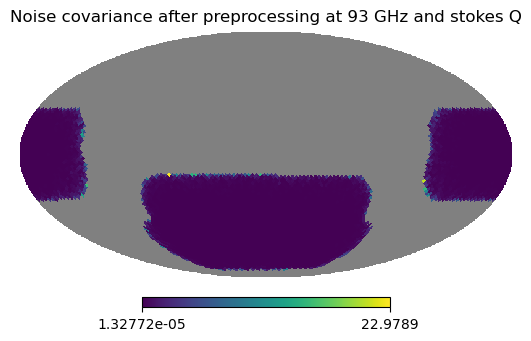

In [21]:
noise_cov_full_sky_beforepreproc = np.load(os.path.join(meta.covmat_directory, 'pixel_noise_cov.npy' ))

apply_nhits_before_udgrade = False # Doing it before yields an error in the component separation, I don't know why, the resulting noise covariance doesn't seem to have any ill defined values (e.g. 0, inf, nan, None...)
                                   # Applying it before would make more sense in my opinion though...
if apply_nhits_before_udgrade:
    nhits_map = meta_nhits_sims.read_hitmap() 
    nhits_map_rescaled = nhits_map / max(nhits_map)
    noise_cov_full_sky_beforepreproc_degraded = np.array([hp.ud_grade(noise_cov_freq / nhits_map_rescaled, nside_out=meta_nhits.nside) for noise_cov_freq in noise_cov_full_sky_beforepreproc])
else:
    noise_cov_full_sky_beforepreproc_degraded = np.array([hp.ud_grade(noise_cov_freq , nside_out=meta_nhits.nside) for noise_cov_freq in noise_cov_full_sky_beforepreproc])

    nhits_map = meta_nhits.read_hitmap() 
    nhits_map_rescaled = nhits_map / max(nhits_map)
    noise_cov_full_sky_beforepreproc_degraded /= nhits_map_rescaled

noise_cov_full_sky_beforepreproc_degraded[..., np.where(binary_mask == 0)[0]] = hp.UNSEEN 

hp.mollview(noise_cov_full_sky_beforepreproc_degraded[freq_index, stokes_index, :], title='Noise covariance after preprocessing at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.show()




In [22]:

time_comp_sep = time.time()
res_masked_afterpreproc_noisecovbeforepreproc = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc[:,1:], cov=noise_cov_full_sky_beforepreproc_degraded[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print(res_masked_afterpreproc)

time comp sep = 1.79941987991333
     Sigma: array([[ 5.89636413e-08, -1.14369684e-07],
       [-1.14369684e-07,  1.87384167e-06]])
 Sigma_inv: array([[19237020.35563103,  1174129.04789291],
       [ 1174129.04789291,   605325.83159585]])
       chi: array([[[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375

In [23]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_afterpreproc_noisecovbeforepreproc.Sigma)
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_afterpreproc_noisecovbeforepreproc.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_afterpreproc_noisecovbeforepreproc.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)
    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc_noisecovbeforepreproc.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc_noisecovbeforepreproc.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc_noisecovbeforepreproc.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc_noisecovbeforepreproc.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc_noisecovbeforepreproc.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc_noisecovbeforepreproc.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.539340529278928
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.9989347736917678
Estimated error matrix = 
 [[ 0.00135809 -0.00052037]
 [-0.00052037  0.00847832]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0006594707210720863
Relative difference in dust index (in %) =  0.042822774095590016
Relative difference in dust index using ouptut Sigma =  0.4855878399101544



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.0010652263082322477
Relative difference in synchrotron index (in %) =  0.035507543607741596
Relative difference in synchrotron index using ouptut Sigma =  0.12564126079619803


# 6) Re-exploring case (4) with **preproceseed** and masked data and noise-covariance but with noise covariance built using diffenrent number of simulations
### a) With nsims = 10

In [24]:
#  For this test the simulated data and outputs are stored in /pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhits
# Let's set up the meta_sims and meta objects.
args_10 = classmethod(None)
args_10.sims = '/pscratch/sd/j/jost/SO_MEGATOP/10SimsNside64to32WithNhits/OnTheFlySims/config.yaml'
args_10.globals = '/pscratch/sd/j/jost/SO_MEGATOP/10SimsNside64to32WithNhits/outputs/config.yaml'

meta_10_sims = BBmeta(args_10.sims)
meta_10 = BBmeta(args_10.globals)

In [26]:
# Let's import the masked data and noise covariance matrix
binary_mask10 = meta_10.read_mask('binary').astype(bool)
freq_maps_masked_afterpreproc10 = np.load(os.path.join(meta_10.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_num).zfill(5)+'.npy' )) 
# Applying mask as it is not done in the simulation
freq_maps_masked_afterpreproc10[..., np.where(binary_mask10 == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)

# Importing the relevant noise covariance matrix
noise_cov_masked_afterpreproc10 = np.load(os.path.join(meta_10.covmat_directory, 'pixel_noise_cov_preprocessed.npy' )) 
# Putting masked pixels to UNSEEN (noise cov is natively masked when using nhits like in this case)
noise_cov_masked_afterpreproc10[..., np.where(binary_mask10 == 0)[0]] = hp.UNSEEN 

Frequency =  93 GHz


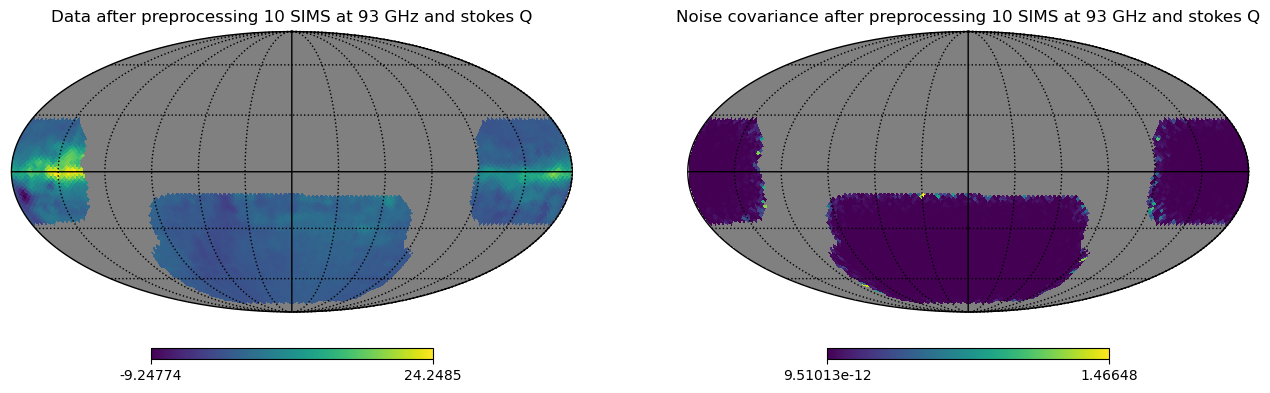

In [36]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_masked_afterpreproc10[freq_index, stokes_index, :], title='Data after preprocessing 10 SIMS at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_masked_afterpreproc10[freq_index, stokes_index, :], title='Noise covariance after preprocessing 10 SIMS at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()

In [28]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_masked_afterpreproc10 = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc10[:,1:], cov=noise_cov_masked_afterpreproc10[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print(res_masked_afterpreproc10)

time comp sep = 3.15557861328125
     Sigma: array([[ 6.39935034e-08, -1.27726039e-07],
       [-1.27726039e-07,  1.85191312e-06]])
 Sigma_inv: array([[18121106.98180366,  1249808.74642648],
       [ 1249808.74642648,   626181.16803228]])
       chi: array([[[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375

In [29]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_afterpreproc10.Sigma)
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_afterpreproc10.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_afterpreproc10.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)
    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc10.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc10.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc10.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc10.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc10.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc10.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5393124752233664
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.9926303063882713
Estimated error matrix = 
 [[ 2.40018905e-04 -7.99026205e-05]
 [-7.99026205e-05  1.35850237e-03]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.0006875247766335857
Relative difference in dust index (in %) =  0.0446444660151679
Relative difference in dust index using ouptut Sigma =  2.8644609374345973



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.007369693611728678
Relative difference in synchrotron index (in %) =  0.24565645372428926
Relative difference in synchrotron index using ouptut Sigma =  5.424866213503652


### b) With nsims = 250

In [30]:
#  For this test the simulated data and outputs are stored in /pscratch/sd/j/jost/SO_MEGATOP/100SimsNside64to32WithNhits
# Let's set up the meta_sims and meta objects.
args_250 = classmethod(None)
args_250.sims = '/pscratch/sd/j/jost/SO_MEGATOP/250SimsNside64to32WithNhits/OnTheFlySims/config.yaml'
args_250.globals = '/pscratch/sd/j/jost/SO_MEGATOP/250SimsNside64to32WithNhits/outputs/config.yaml'

meta_250_sims = BBmeta(args_250.sims)
meta_250 = BBmeta(args_250.globals)

In [31]:
# Let's import the masked data and noise covariance matrix
binary_mask250 = meta_250.read_mask('binary').astype(bool)
freq_maps_masked_afterpreproc250 = np.load(os.path.join(meta_250.pre_process_directory, 'freq_maps_common_beamed_masked'+str(sim_num).zfill(5)+'.npy' )) 
# Applying mask as it is not done in the simulation
freq_maps_masked_afterpreproc250[..., np.where(binary_mask250 == 0)[0]] = hp.UNSEEN # UNSEEN is necessary for the separation (masking to 0 will raise an error)

# Importing the relevant noise covariance matrix
noise_cov_masked_afterpreproc250 = np.load(os.path.join(meta_250.covmat_directory, 'pixel_noise_cov_preprocessed.npy' )) 
# Putting masked pixels to UNSEEN (noise cov is natively masked when using nhits like in this case)
noise_cov_masked_afterpreproc250[..., np.where(binary_mask250 == 0)[0]] = hp.UNSEEN 

Frequency =  93 GHz


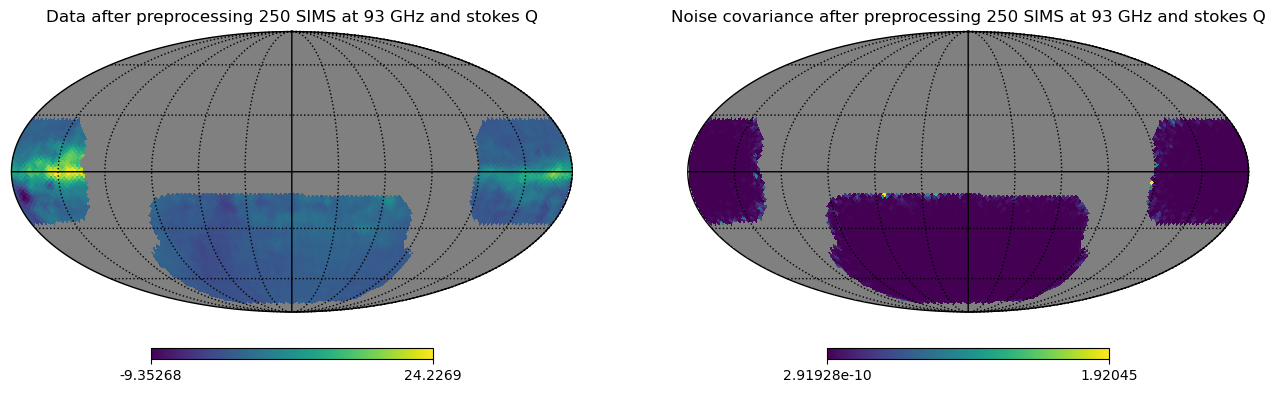

In [37]:
#  For good measure, let's plot one of the map from the data and the noise covariance matrix at frequency 93 GHz and stokes Q
freq_index = 2
print('Frequency = ', meta.frequencies[freq_index], 'GHz')
stokes_index = 1 # Q

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
plt.sca(axes[0]) 
hp.mollview(freq_maps_masked_afterpreproc250[freq_index, stokes_index, :], title='Data after preprocessing 250 SIMS at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
plt.sca(axes[1]) 
hp.mollview(noise_cov_masked_afterpreproc250[freq_index, stokes_index, :], title='Noise covariance after preprocessing 250 SIMS at '+str(meta.frequencies[freq_index])+' GHz and stokes Q', hold=True)
hp.graticule()
plt.show()

In [39]:
# Running the separation using the same parameters as before
time_comp_sep = time.time()
res_masked_afterpreproc250 = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=freq_maps_masked_afterpreproc250[:,1:], cov=noise_cov_masked_afterpreproc250[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)

# We can now check the results
print(res_masked_afterpreproc10)

time comp sep = 2.000124216079712
     Sigma: array([[ 6.50363099e-08, -1.28271701e-07],
       [-1.28271701e-07,  1.81770459e-06]])
 Sigma_inv: array([[17862106.64159874,  1260492.39143825],
       [ 1260492.39143825,   639094.77499977]])
       chi: array([[[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30]],

       [[-1.6375e+30, -1.6375e+30, -1.6375e+30, ..., -1.6375e+30,
         -1.6375e+30, -1.6375e+30],
        [-1.6375e+30, -1.637

In [40]:
if meta_sims.dust_model == 'd0' and meta_sims.sync_model == 's0':
    print('Checking difference with input d0 s0 indices')
    sky = Sky(nside=64, preset_strings=["d0",'s0'])
    sigma_from_fisher = scipy.linalg.sqrtm(res_masked_afterpreproc250.Sigma)
    print('Input dust index = ', sky.components[0].mbb_index , '          Estimated dust index = ', res_masked_afterpreproc250.x[0])
    print('Input synchrotron index = ', sky.components[1].pl_index, '   Estimated synchrotron index = ', res_masked_afterpreproc250.x[1])
    print('Estimated error matrix = \n', sigma_from_fisher)
    print('\n')
    print('============= DUST INDEX ==============')
    print('Absolute difference in dust index = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc250.x[0]))
    print('Relative difference in dust index (in %) = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc250.x[0])/sky.components[0].mbb_index *100)
    print('Relative difference in dust index using ouptut Sigma = ', np.abs(sky.components[0].mbb_index - res_masked_afterpreproc250.x[0])/ sigma_from_fisher[0,0] )
    print('\n\n')
    print('============= SYNCHROTRON INDEX ==============')
    print('Absolute difference in synchrotron index = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc250.x[1]))
    print('Relative difference in synchrotron index (in %) = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc250.x[1])/np.abs(sky.components[1].pl_index ) *100)
    print('Relative difference in synchrotron index using ouptut Sigma = ', np.abs(sky.components[1].pl_index - res_masked_afterpreproc250.x[1])/ sigma_from_fisher[1,1] )

Checking difference with input d0 s0 indices
Input dust index =  1.54           Estimated dust index =  1.5388906418235575
Input synchrotron index =  -3.0    Estimated synchrotron index =  -2.987155059545201
Estimated error matrix = 
 [[ 2.41886396e-04 -8.07915916e-05]
 [-8.07915916e-05  1.34579988e-03]]


============= DUST INDEX ==============
Absolute difference in dust index =  0.001109358176442532
Relative difference in dust index (in %) =  0.07203624522354103
Relative difference in dust index using ouptut Sigma =  4.58627766714483



============= SYNCHROTRON INDEX ==============
Absolute difference in synchrotron index =  0.012844940454798781
Relative difference in synchrotron index (in %) =  0.42816468182662604
Relative difference in synchrotron index using ouptut Sigma =  9.544465482382975
